In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_excel("C:/Users/Dell/Desktop/projrct work/PAYROLL_CLEANED.xlsx")


In [8]:
df.head()

,PAY_YEAR,DEPARTMENT_NO,DEPARTMENT_TITLE,JOB_CLASS_PGRADE,JOB_TITLE,EMPLOYMENT_TYPE,JOB_STATUS,MOU_TITLE,REGULAR_PAY,OVERTIME_PAY,ALL_OTHER_PAY,TOTAL_PAY,CITY_RETIREMENT_CONTRIBUTIONS,BENEFIT_PAY,GENDER,ETHNICITY
0,2017,98,WATER AND POWER,3156,CUSTODIAN,FULL_TIME,ACTIVE,OPERATING MAINTENANCE AND SERVICE UNIT,55725.24,4785.05,2021.84,62532.13,3678.0,23508.9,FEMALE,HISPANIC
1,2017,98,WATER AND POWER,9105,UTILITY ADMINISTRATOR,FULL_TIME,ACTIVE,MANAGEMENT EMPLOYEES UNIT,139174.88,16340.50,6170.49,161685.87,9186.0,23508.9,FEMALE,ASIAN AMERICAN
2,2017,98,WATER AND POWER,9602,WATER SERVICES MANAGER,FULL_TIME,ACTIVE,MANAGEMENT EMPLOYEES UNIT,245879.12,0.00,12504.30,258383.42,16228.0,23508.9,MALE,BLACK
3,2017,98,WATER AND POWER,5885,WTR TRTMT OPR,FULL_TIME,ACTIVE,STEAM PLANT AND WATER SUPPLY UNIT,101494.34,7824.99,12630.52,121949.85,6699.0,23508.9,MALE,ASIAN AMERICAN
4,2017,98,WATER AND POWER,3841,ELTL MCHC,FULL_TIME,ACTIVE,OPERATING MAINTENANCE AND SERVICE UNIT,101345.12,22284.37,1566.75,125196.24,6689.0,23508.9,MALE,HISPANIC


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PAY_YEAR                       1500 non-null   int64  
 1   DEPARTMENT_NO                  1500 non-null   int64  
 2   DEPARTMENT_TITLE               1500 non-null   object 
 3   JOB_CLASS_PGRADE               1500 non-null   int64  
 4   JOB_TITLE                      1500 non-null   object 
 5   EMPLOYMENT_TYPE                1500 non-null   object 
 6   JOB_STATUS                     1500 non-null   object 
 7   MOU_TITLE                      1500 non-null   object 
 8   REGULAR_PAY                    1500 non-null   float64
 9   OVERTIME_PAY                   1500 non-null   float64
 10  ALL_OTHER_PAY                  1500 non-null   float64
 11  TOTAL_PAY                      1500 non-null   float64
 12  CITY_RETIREMENT_CONTRIBUTIONS  1500 non-null   f

# cleaning

In [10]:
print(df.isnull().sum())

PAY_YEAR                         0
DEPARTMENT_NO                    0
DEPARTMENT_TITLE                 0
JOB_CLASS_PGRADE                 0
JOB_TITLE                        0
EMPLOYMENT_TYPE                  0
JOB_STATUS                       0
MOU_TITLE                        0
REGULAR_PAY                      0
OVERTIME_PAY                     0
ALL_OTHER_PAY                    0
TOTAL_PAY                        0
CITY_RETIREMENT_CONTRIBUTIONS    0
BENEFIT_PAY                      0
GENDER                           0
ETHNICITY                        0
dtype: int64


In [11]:
print(df.duplicated().sum())

0


In [12]:
print(df.dtypes)

PAY_YEAR                           int64
DEPARTMENT_NO                      int64
DEPARTMENT_TITLE                  object
JOB_CLASS_PGRADE                   int64
JOB_TITLE                         object
EMPLOYMENT_TYPE                   object
JOB_STATUS                        object
MOU_TITLE                         object
REGULAR_PAY                      float64
OVERTIME_PAY                     float64
ALL_OTHER_PAY                    float64
TOTAL_PAY                        float64
CITY_RETIREMENT_CONTRIBUTIONS    float64
BENEFIT_PAY                      float64
GENDER                            object
ETHNICITY                         object
dtype: object


# Visualization

# 1. Salary distribution (how salaries are spread)?

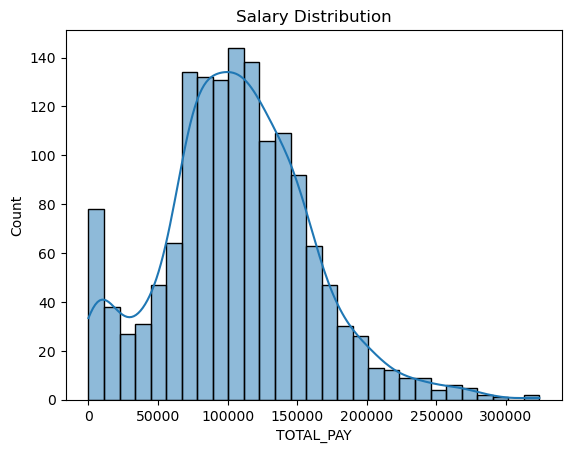

In [16]:
sns.histplot(df['TOTAL_PAY'], kde=True)
plt.title("Salary Distribution")
plt.show()

#conclusion:Salaries are mostly concentrated in the mid-range, with a few high-value outliers creating a right-skewed distribution.

# 2. Gender-wise salary comparison?

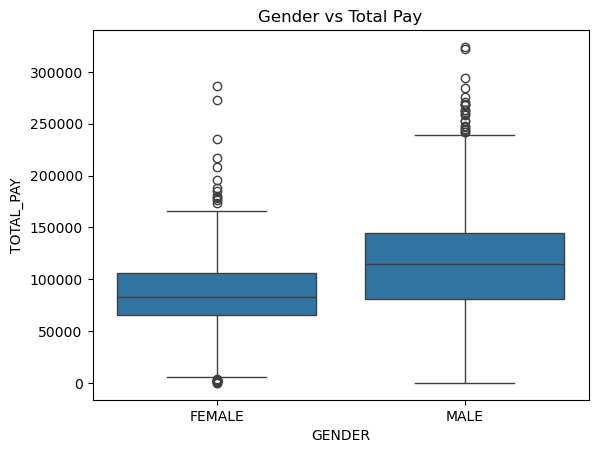

In [17]:
sns.boxplot(x='GENDER', y='TOTAL_PAY', data=df)
plt.title("Gender vs Total Pay")
plt.show()

In [ ]:
#conclusion:Males have slightly higher pay and more variability than females.

 # 3. Which job title gets highest average salary?
 

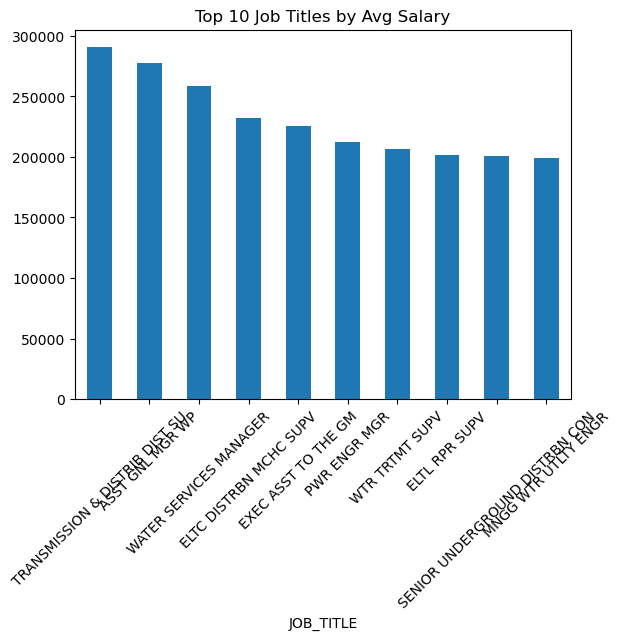

In [19]:
job_salary = df.groupby('JOB_TITLE')['TOTAL_PAY'].mean().sort_values(ascending=False).head(10)

job_salary.plot(kind='bar')
plt.title("Top 10 Job Titles by Avg Salary")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# conclusion:Males earn slightly more with higher variability, while the top-paying role is District Superintendent.

# 4.Department-wise average salary?

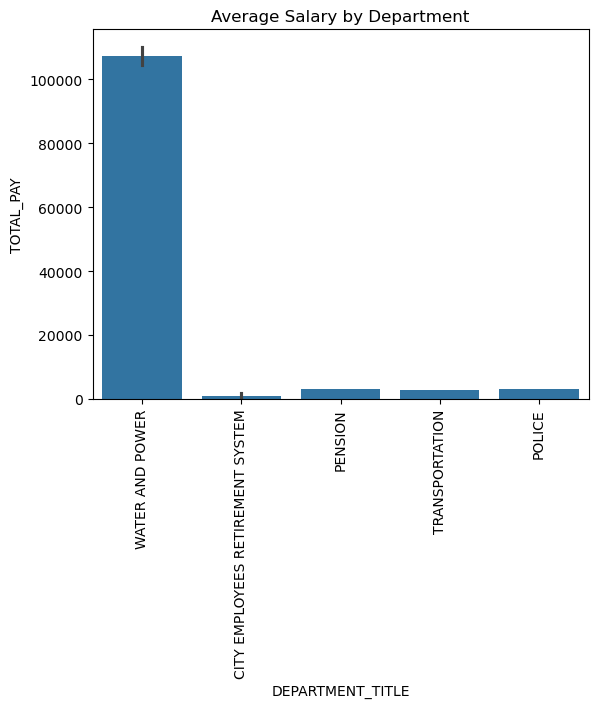

In [20]:
sns.barplot(x='DEPARTMENT_TITLE', y='TOTAL_PAY', data=df)
plt.xticks(rotation=90)
plt.title("Average Salary by Department")
plt.show()

# conclusion:jTop earners are *District Superintendent* by job title and *"ND POWER"* department, both far outpacing other roles and departments.

# 5.Employment type distribution

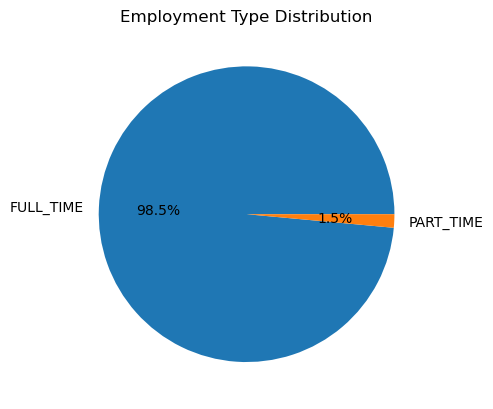

In [22]:
df['EMPLOYMENT_TYPE'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Employment Type Distribution")
plt.ylabel("")
plt.show()

# 6. Top 5 highest paid employees (by job title)

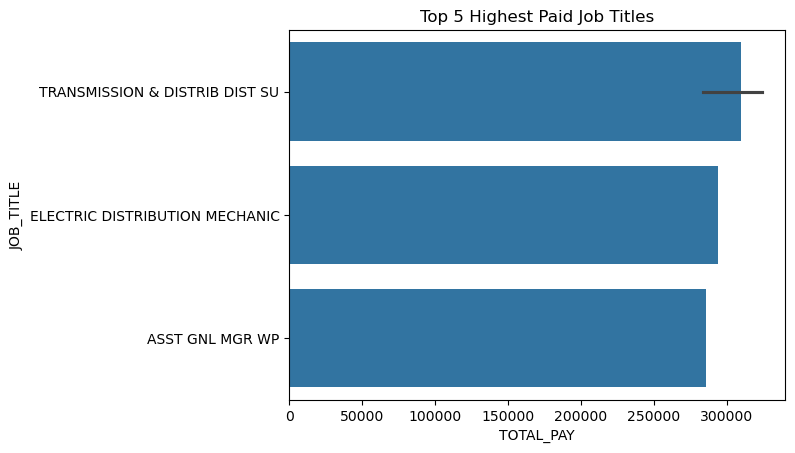

In [23]:
top5 = df.nlargest(5, 'TOTAL_PAY')

sns.barplot(x='TOTAL_PAY', y='JOB_TITLE', data=top5)
plt.title("Top 5 Highest Paid Job Titles")
plt.show()

# 7. Benefit pay vs total pay

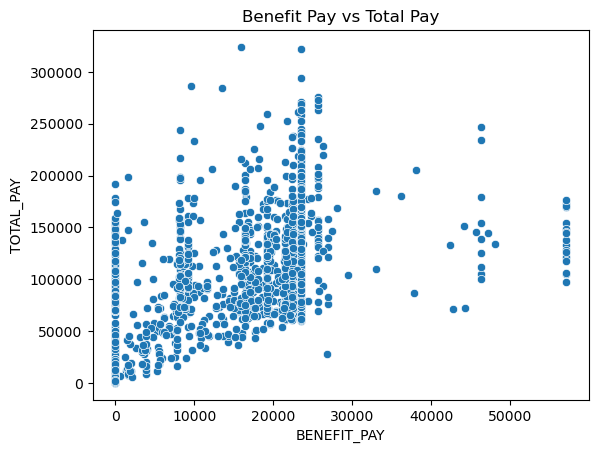

In [24]:
sns.scatterplot(x='BENEFIT_PAY', y='TOTAL_PAY', data=df)
plt.title("Benefit Pay vs Total Pay")
plt.show()

# 8. Ethnicity distribution

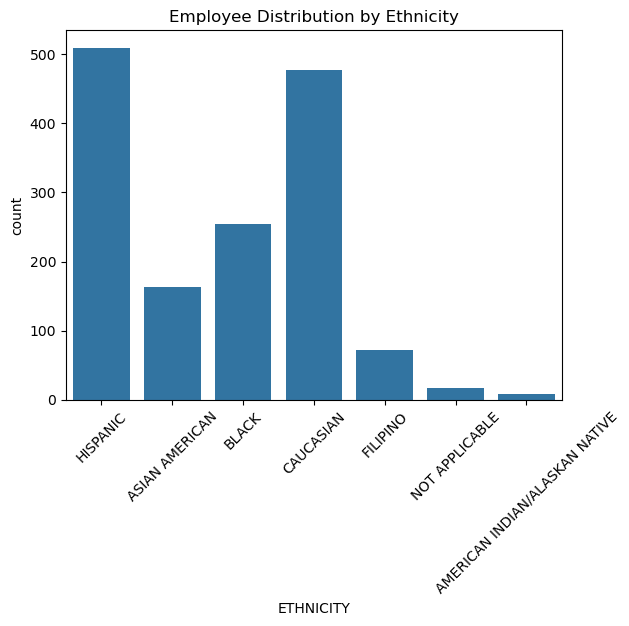

In [25]:
sns.countplot(x='ETHNICITY', data=df)
plt.xticks(rotation=45)
plt.title("Employee Distribution by Ethnicity")
plt.show()

# 9.Which gender works more overtime?

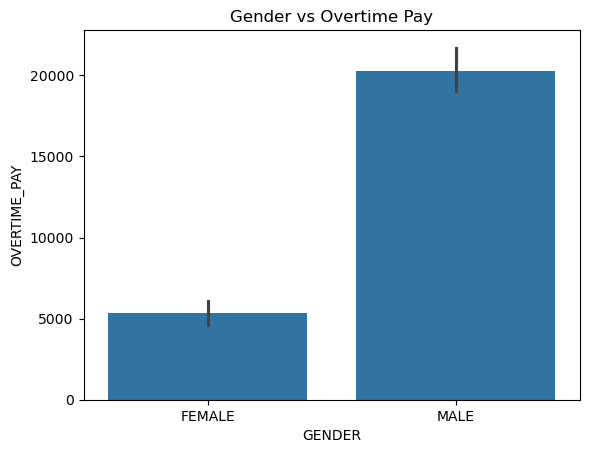

In [33]:
sns.barplot(x='GENDER', y='OVERTIME_PAY', data=df)
plt.title("Gender vs Overtime Pay")
plt.show()

# 10.Full-time vs part-time salary comparison

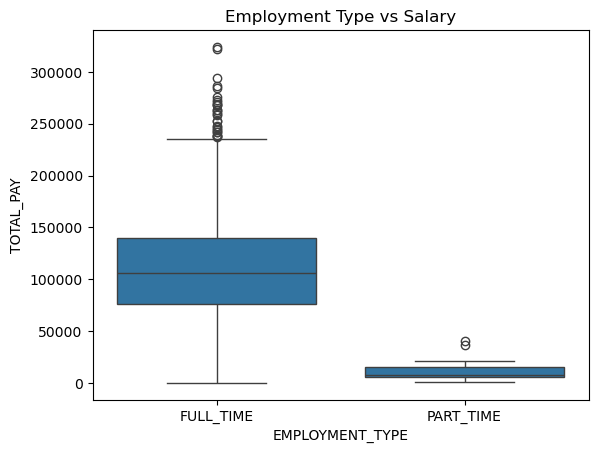

In [37]:
sns.boxplot(x='EMPLOYMENT_TYPE', y='TOTAL_PAY', data=df)
plt.title("Employment Type vs Salary")
plt.show()

# 11.Correlation between numeric features

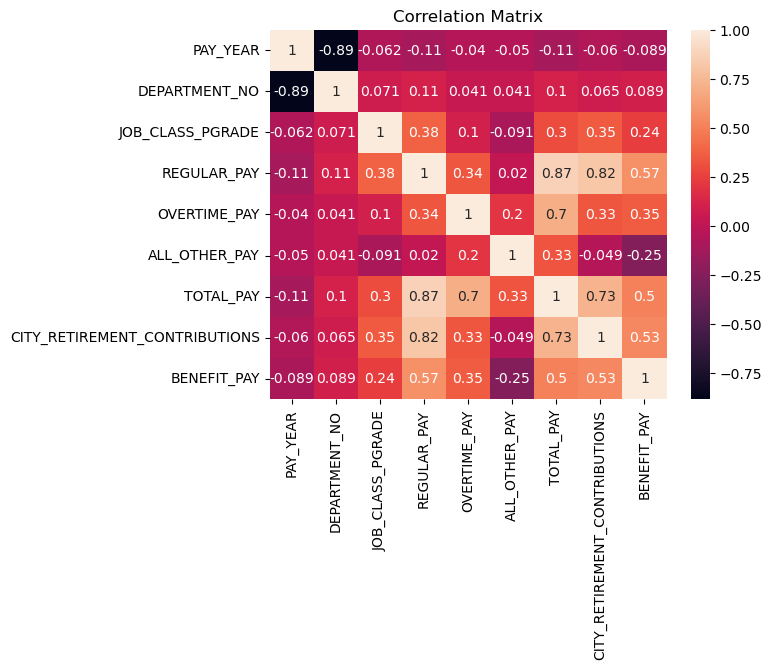

In [39]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [40]:
# 12.Which job titles are most common?

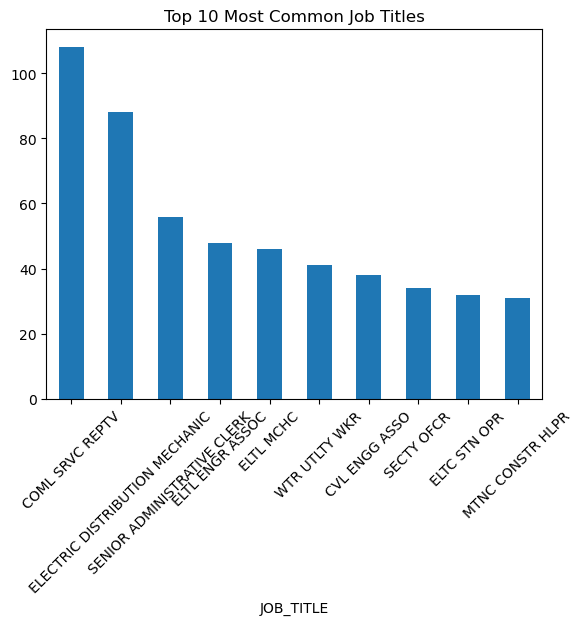

In [41]:
df['JOB_TITLE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Common Job Titles")
plt.xticks(rotation=45)
plt.show()

In [46]:
# 13.Highest paying department for each employment type

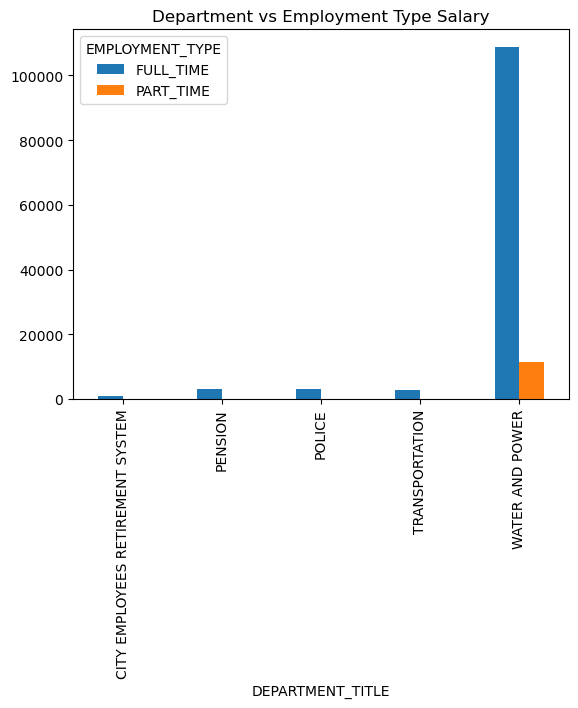

In [47]:
pivot = df.pivot_table(values='TOTAL_PAY', index='DEPARTMENT_TITLE', columns='EMPLOYMENT_TYPE', aggfunc='mean')

pivot.plot(kind='bar')
plt.xticks(rotation=90)
plt.title("Department vs Employment Type Salary")
plt.show()